# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [8]:
# untuk plot Q-Q
import scipy.stats as stats

In [9]:
df_california = pd.read_csv('california_dataset.csv')

In [10]:
from sklearn.model_selection import train_test_split

# Splitting terlebih dahulu
X = df_california.drop(columns=['house_price'])
y = df_california['house_price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")

# Gabungkan kembali untuk kemudahan handling
df_train = X_train.copy()
df_train['house_price'] = y_train

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

X_train shape: (16512, 8)
X_test shape : (4128, 8)


### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

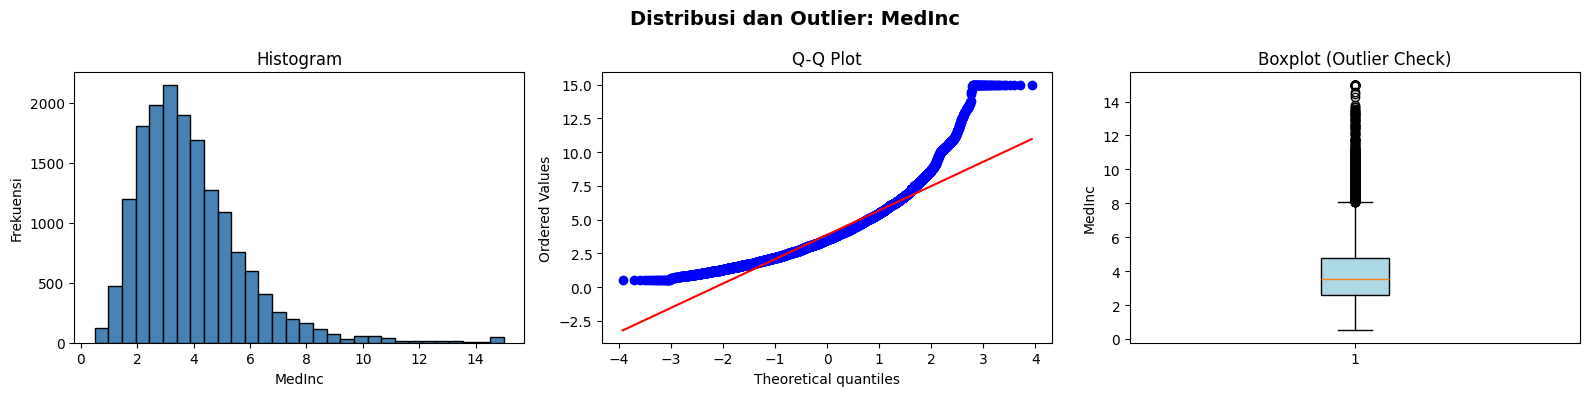

------------------------------------------------------------


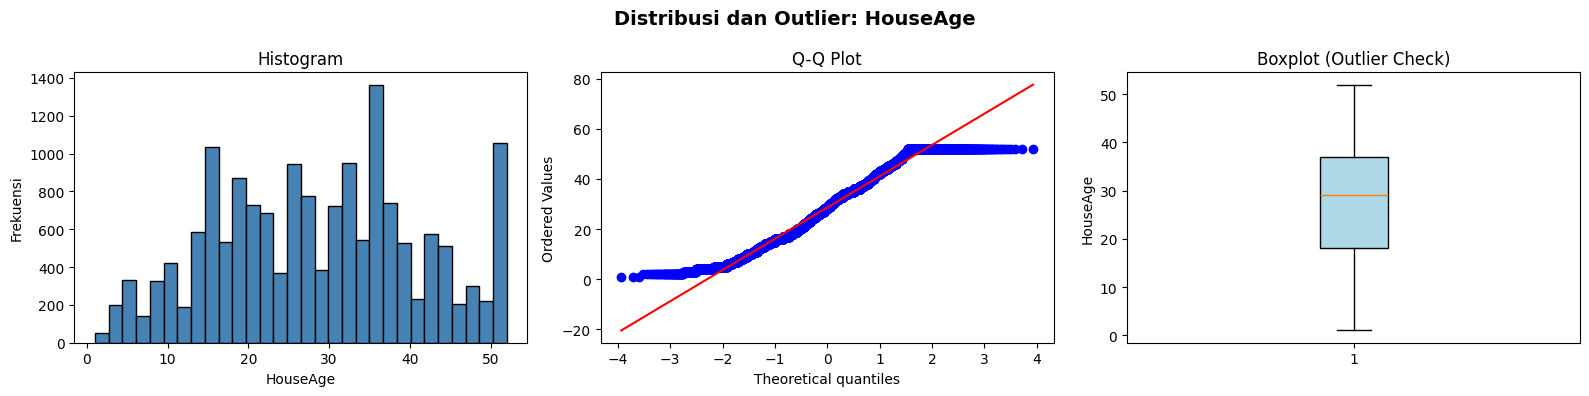

------------------------------------------------------------


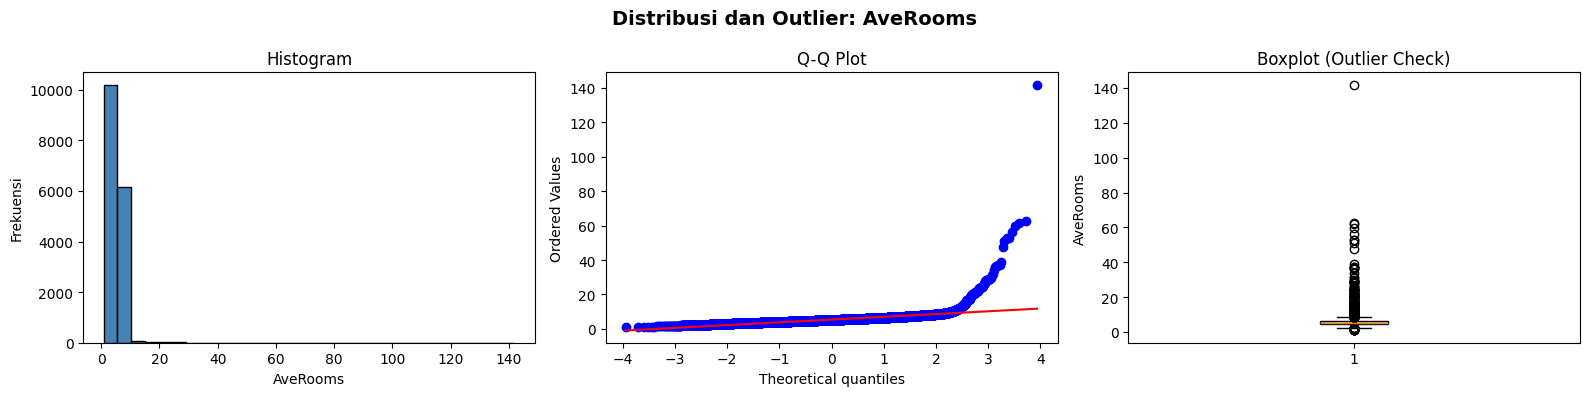

------------------------------------------------------------


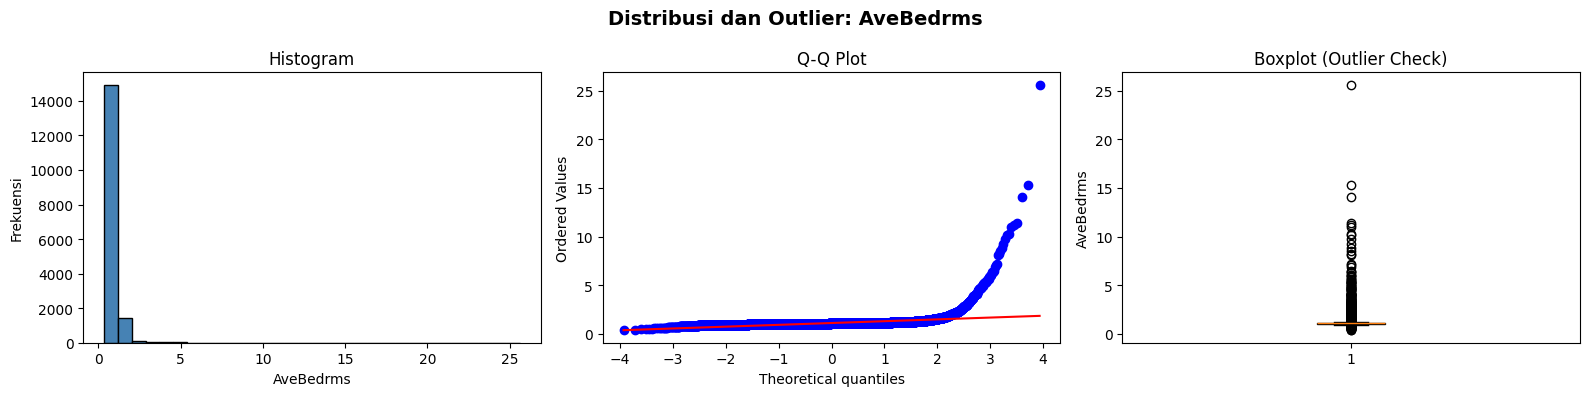

------------------------------------------------------------


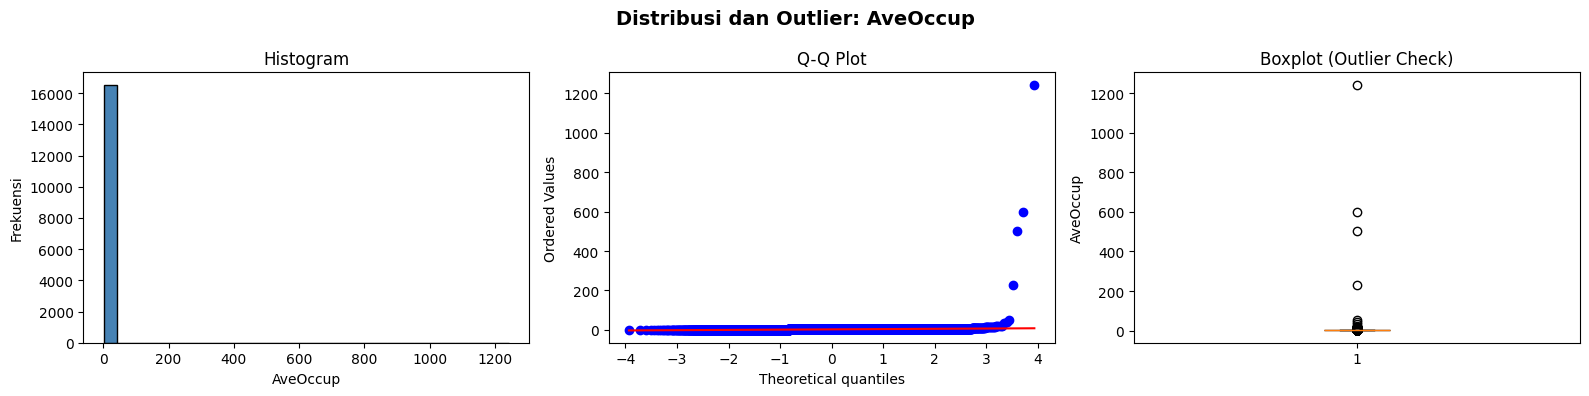

------------------------------------------------------------


In [11]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for kolom in kolom_kolom:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Distribusi dan Outlier: {kolom}', fontsize=14, fontweight='bold')

    # 1. Histogram
    axes[0].hist(df_train[kolom], bins=30, color='steelblue', edgecolor='black')
    axes[0].set_title('Histogram')
    axes[0].set_xlabel(kolom)
    axes[0].set_ylabel('Frekuensi')

    # 2. Q-Q Plot
    stats.probplot(df_train[kolom], dist="norm", plot=axes[1])
    axes[1].set_title('Q-Q Plot')

    # 3. Boxplot
    axes[2].boxplot(df_train[kolom], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue'))
    axes[2].set_title('Boxplot (Outlier Check)')
    axes[2].set_ylabel(kolom)

    plt.tight_layout()
    plt.show()
    print("-" * 60)

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

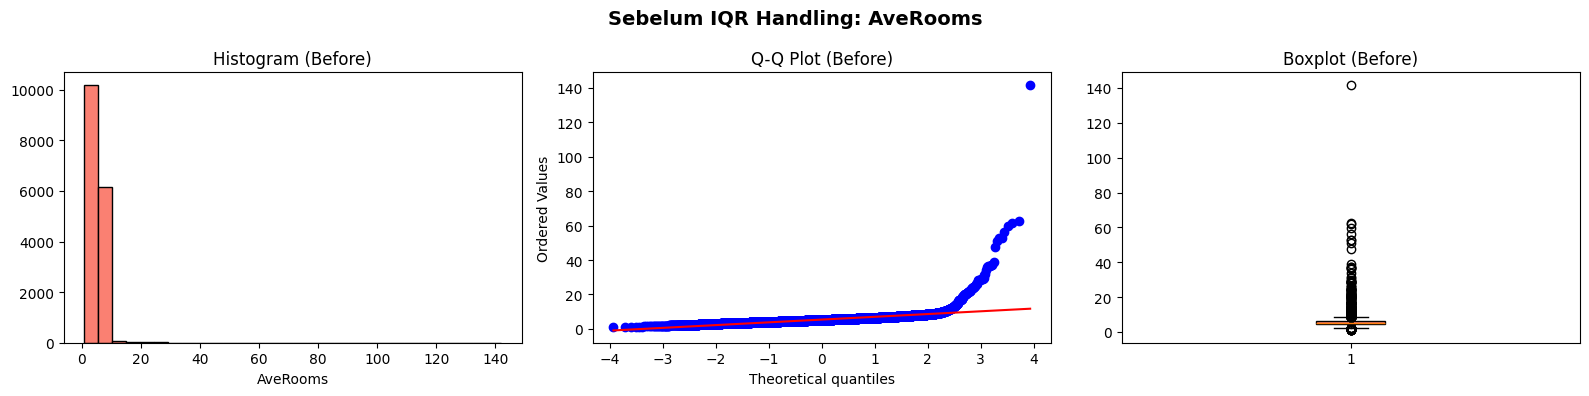

Q1: 4.4521, Q3: 6.0610, IQR: 1.6090
Lower Bound: 2.0386, Upper Bound: 8.4745
Jumlah outlier: 410
Jumlah data sebelum handling: 16512
Jumlah data setelah handling : 16102


In [12]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali

# Kolom yang dipilih: 'AveRooms' (memiliki outlier paling banyak berdasarkan boxplot)
kolom_handling = 'AveRooms'

# Sebelum handling — cek distribusi
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Sebelum IQR Handling: {kolom_handling}', fontsize=14, fontweight='bold')

axes[0].hist(df_train[kolom_handling], bins=30, color='salmon', edgecolor='black')
axes[0].set_title('Histogram (Before)')
axes[0].set_xlabel(kolom_handling)

stats.probplot(df_train[kolom_handling], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Before)')

axes[2].boxplot(df_train[kolom_handling], patch_artist=True, boxprops=dict(facecolor='salmon'))
axes[2].set_title('Boxplot (Before)')

plt.tight_layout()
plt.show()

# ---- IQR Outlier Handling ----
Q1 = df_train[kolom_handling].quantile(0.25)
Q3 = df_train[kolom_handling].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.4f}, Q3: {Q3:.4f}, IQR: {IQR:.4f}")
print(f"Lower Bound: {lower_bound:.4f}, Upper Bound: {upper_bound:.4f}")
print(f"Jumlah outlier: {((df_train[kolom_handling] < lower_bound) | (df_train[kolom_handling] > upper_bound)).sum()}")

# Hapus outlier dari data train saja
df_train_clean = df_train[(df_train[kolom_handling] >= lower_bound) & (df_train[kolom_handling] <= upper_bound)].copy()

print(f"Jumlah data sebelum handling: {len(df_train)}")
print(f"Jumlah data setelah handling : {len(df_train_clean)}")

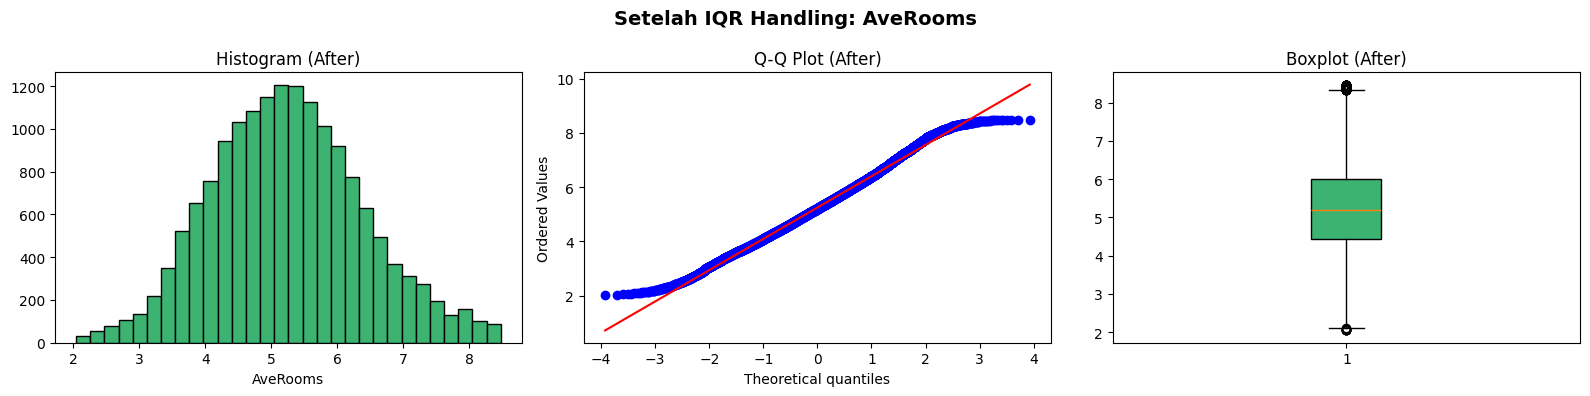

Distribusi AveRooms lebih normal dan outlier telah dihapus dari data train.


In [13]:
# Melakukan loop untuk mengecek distribusi tiap kolom — Setelah IQR Handling

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle(f'Setelah IQR Handling: {kolom_handling}', fontsize=14, fontweight='bold')

axes[0].hist(df_train_clean[kolom_handling], bins=30, color='mediumseagreen', edgecolor='black')
axes[0].set_title('Histogram (After)')
axes[0].set_xlabel(kolom_handling)

stats.probplot(df_train_clean[kolom_handling], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (After)')

axes[2].boxplot(df_train_clean[kolom_handling], patch_artist=True, boxprops=dict(facecolor='mediumseagreen'))
axes[2].set_title('Boxplot (After)')

plt.tight_layout()
plt.show()

print("Distribusi AveRooms lebih normal dan outlier telah dihapus dari data train.")

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [14]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [15]:
from sklearn.model_selection import train_test_split

# Splitting terlebih dahulu
df_train_company, df_test_company = train_test_split(df_company, test_size=0.2, random_state=42)

print(f"Train shape: {df_train_company.shape}")
print(f"Test shape : {df_test_company.shape}")

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

Train shape: (537, 4)
Test shape : (135, 4)


## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [16]:
#Tulis jawaban missing value handling kolom Headquarters disini

# 1. Cek persentase missing value pada kolom Headquarters
# Nilai -1 merupakan nilai tidak valid (bukan lokasi) yang dianggap sebagai missing value
print("=== Cek Missing Value pada kolom Headquarters ===")
print(f"Jenis missing value: nilai '-1' (bukan nama lokasi yang valid)")

jumlah_missing = (df_train_company['Headquarters'] == '-1').sum()
persen_missing = jumlah_missing / len(df_train_company) * 100

print(f"\nJumlah missing value ('-1') : {jumlah_missing}")
print(f"Persentase missing value    : {persen_missing:.2f}%")
print(f"Tipe data kolom             : {df_train_company['Headquarters'].dtype} (kategorik)")

# 2. Keputusan: drop atau tidak?
print("\n=== Keputusan ===")
if persen_missing > 20:
    print(f"Persentase {persen_missing:.2f}% > 20% → KOLOM DI-DROP")
    df_train_company = df_train_company.drop(columns=['Headquarters'])
else:
    print(f"Persentase {persen_missing:.2f}% ≤ 20% → TIDAK DI-DROP, dilakukan handling")

    # 3. Handling: karena tipe kategorik → gunakan Modus
    modus_hq = df_train_company['Headquarters'][df_train_company['Headquarters'] != '-1'].mode()[0]
    print(f"\nModus kolom Headquarters: '{modus_hq}'")
    print("Karena tipe data kategorik → handling menggunakan MODUS")

    # Ganti nilai -1 dengan modus
    df_train_company['Headquarters'] = df_train_company['Headquarters'].replace('-1', modus_hq)

    # Validasi
    print(f"\nSisa nilai '-1' setelah handling: {(df_train_company['Headquarters'] == '-1').sum()}")
    print("\nTop 5 value counts setelah handling:")
    print(df_train_company['Headquarters'].value_counts().head())

=== Cek Missing Value pada kolom Headquarters ===
Jenis missing value: nilai '-1' (bukan nama lokasi yang valid)

Jumlah missing value ('-1') : 24
Persentase missing value    : 4.47%
Tipe data kolom             : object (kategorik)

=== Keputusan ===
Persentase 4.47% ≤ 20% → TIDAK DI-DROP, dilakukan handling

Modus kolom Headquarters: 'New York, NY'
Karena tipe data kategorik → handling menggunakan MODUS

Sisa nilai '-1' setelah handling: 0

Top 5 value counts setelah handling:
Headquarters
New York, NY         53
San Francisco, CA    28
Chicago, IL          20
Boston, MA           13
Mc Lean, VA          12
Name: count, dtype: int64


In [17]:
# Validasi akhir — pastikan tidak ada missing value tersembunyi
print("Info kolom Headquarters setelah handling:")
print(df_train_company['Headquarters'].describe())

Info kolom Headquarters setelah handling:
count              537
unique             196
top       New York, NY
freq                53
Name: Headquarters, dtype: object


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [18]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [19]:
# Splitting terlebih dahulu
df_train_churn, df_test_churn = train_test_split(df_churn, test_size=0.2, random_state=42)

print(f"Train shape: {df_train_churn.shape}")
print(f"Test shape : {df_test_churn.shape}")

Train shape: (5634, 21)
Test shape : (1409, 21)


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [20]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

# 1. Kolom-kolom yang akan di-Label Encode
kolom_label = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection',
               'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

# 2. Ganti nilai yang tidak sesuai
# - 'No internet service' → 'No' (untuk kolom selain MultipleLines)
# - 'No phone service'    → 'No' (untuk kolom MultipleLines)
print("=== Mengganti nilai tidak sesuai ===")

for kolom in kolom_label:
    if kolom == 'MultipleLines':
        df_train_churn[kolom] = df_train_churn[kolom].replace('No phone service', 'No')
    else:
        df_train_churn[kolom] = df_train_churn[kolom].replace('No internet service', 'No')

# Validasi dengan value_counts
print("Value counts setelah penggantian nilai:")
for kolom in kolom_label:
    print(f"\n{kolom}:")
    print(df_train_churn[kolom].value_counts())

=== Mengganti nilai tidak sesuai ===
Value counts setelah penggantian nilai:

StreamingMovies:
StreamingMovies
No     3437
Yes    2197
Name: count, dtype: int64

StreamingTV:
StreamingTV
No     3453
Yes    2181
Name: count, dtype: int64

TechSupport:
TechSupport
No     4005
Yes    1629
Name: count, dtype: int64

DeviceProtection:
DeviceProtection
No     3703
Yes    1931
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No     3662
Yes    1972
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No     4024
Yes    1610
Name: count, dtype: int64

MultipleLines:
MultipleLines
No     3237
Yes    2397
Name: count, dtype: int64


In [21]:
# 3. Lakukan Label Encoding
le = LabelEncoder()

print("=== Label Encoding ===")
for kolom in kolom_label:
    df_train_churn[kolom] = le.fit_transform(df_train_churn[kolom])
    print(f"{kolom}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print("\nDataframe setelah Label Encoding (kolom terpilih):")
print(df_train_churn[kolom_label].head())

=== Label Encoding ===
StreamingMovies: {'No': np.int64(0), 'Yes': np.int64(1)}
StreamingTV: {'No': np.int64(0), 'Yes': np.int64(1)}
TechSupport: {'No': np.int64(0), 'Yes': np.int64(1)}
DeviceProtection: {'No': np.int64(0), 'Yes': np.int64(1)}
OnlineBackup: {'No': np.int64(0), 'Yes': np.int64(1)}
OnlineSecurity: {'No': np.int64(0), 'Yes': np.int64(1)}
MultipleLines: {'No': np.int64(0), 'Yes': np.int64(1)}

Dataframe setelah Label Encoding (kolom terpilih):
      StreamingMovies  StreamingTV  TechSupport  DeviceProtection  \
2142                1            0            0                 1   
1623                1            1            0                 0   
6074                0            0            0                 0   
1362                0            0            0                 0   
6754                0            0            1                 0   

      OnlineBackup  OnlineSecurity  MultipleLines  
2142             0               1              0  
1623             1  

In [22]:
# Validasi tipe data setelah encoding
print("Tipe data kolom setelah Label Encoding:")
print(df_train_churn[kolom_label].dtypes)

Tipe data kolom setelah Label Encoding:
StreamingMovies     int64
StreamingTV         int64
TechSupport         int64
DeviceProtection    int64
OnlineBackup        int64
OnlineSecurity      int64
MultipleLines       int64
dtype: object


In [23]:
# Ringkasan proses encoding
print("=== Ringkasan Label Encoding ===")
print(f"Kolom yang di-encode: {kolom_label}")
print("Mapping: No → 0, Yes → 1")
print(f"\nShape df_train_churn setelah encoding: {df_train_churn.shape}")
print("\nSample hasil encoding:")
print(df_train_churn[kolom_label].sample(5, random_state=42))

=== Ringkasan Label Encoding ===
Kolom yang di-encode: ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']
Mapping: No → 0, Yes → 1

Shape df_train_churn setelah encoding: (5634, 21)

Sample hasil encoding:
      StreamingMovies  StreamingTV  TechSupport  DeviceProtection  \
3575                1            1            1                 0   
4958                0            1            0                 0   
1447                0            0            1                 0   
3334                1            1            0                 1   
4041                1            1            1                 1   

      OnlineBackup  OnlineSecurity  MultipleLines  
3575             0               0              0  
4958             1               1              1  
1447             0               0              1  
3334             1               0              1  
4041             0               1              0

## Selesai :)